# ???????????? ?????? 2: ????????????

??????? ???????? ?????? ??? ??? ??????? ????????????? ? ?????????? ???????? ?? ?????????. ?????? ????? ????????? ?? ????????; ??????? ?? ????????? ? ?? ????????????? ???????.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import scipy
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.datasets import load_svmlight_file
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC = ROOT / 'src'
DATA = ROOT / 'notebooks' / 'data'
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from opt_project_team_3.src.optimization import (
    gradient_descent,
    newton,
    linear_conjugate_gradients,
    nonlinear_conjugate_gradients,
    lbfgs,
    hessian_free_newton,
)

from opt_project_team_3.src.oracles import QuadraticOracle, RidgeL2Oracle, ProbitL2Oracle, hess_vec_finite_diff
from opt_project_team_3.src.utils import LineSearchTool

plt.style.use('default')


## ????? ???????

In [2]:
REGRESSION_DATASETS = ['housing_scale', 'pyrim']
CLASSIFICATION_DATASETS = ['w8a', 'colon-cancer']


def load_data(name):
    return load_svmlight_file(str(DATA / f'{name}.txt'))


def prepare_labels(y, task):
    y = np.asarray(y, dtype=float)
    if task == 'classification':
        return np.where(y > 0, 1.0, -1.0)
    return y


def matmat_ATsA(A, s):
    if sp.issparse(A):
        return A.T @ sp.diags(s) @ A
    return A.T @ (s[:, None] * A)


def make_oracle(A, y, task, regcoef=None):
    y = prepare_labels(y, task)
    m, n = A.shape
    regcoef = 1.0 / m if regcoef is None else regcoef
    if task == 'regression':
        return RidgeL2Oracle(
            lambda x: A @ x,
            lambda z: A.T @ z,
            lambda s: matmat_ATsA(A, s),
            y,
            regcoef,
        )
    return ProbitL2Oracle(
        lambda x: A @ x,
        lambda z: A.T @ z,
        lambda s: matmat_ATsA(A, s),
        y,
        regcoef,
        matvec_ATx_sqr=lambda s: A.multiply(A).T @ s if sp.issparse(A) else (A ** 2).T @ s,
    )


class DenseHessianOracle:
    def __init__(self, oracle):
        self.oracle = oracle

    def func(self, x):
        return self.oracle.func(x)

    def grad(self, x):
        return self.oracle.grad(x)

    def hess(self, x):
        H = self.oracle.hess(x)
        return H.toarray() if sp.issparse(H) else H

    def hess_vec(self, x, v):
        return self.oracle.hess_vec(x, v)

    def func_directional(self, x, d, alpha):
        return self.oracle.func_directional(x, d, alpha)

    def grad_directional(self, x, d, alpha):
        return self.oracle.grad_directional(x, d, alpha)


def rel_grad_sq(history):
    g = np.asarray(history['grad_norm'])
    return (g / (g[0] + 1e-16)) ** 2


def iterations(history, key='grad_norm'):
    return len(history.get(key, []))


def plot_rel_grad_by_iter(results, title):
    plt.figure(figsize=(8, 5))
    for name, hist in results.items():
        plt.semilogy(rel_grad_sq(hist), linewidth=2, label=name)
    plt.xlabel('iteration')
    plt.ylabel(r'$||\nabla f(x_k)||^2 / ||\nabla f(x_0)||^2$')
    plt.title(title)
    plt.grid(True)
    plt.legend()


def plot_rel_grad_by_time(results, title):
    plt.figure(figsize=(8, 5))
    for name, hist in results.items():
        plt.semilogy(hist['time'], rel_grad_sq(hist), linewidth=2, label=name)
    plt.xlabel('time, sec')
    plt.ylabel(r'$||\nabla f(x_k)||^2 / ||\nabla f(x_0)||^2$')
    plt.title(title)
    plt.grid(True)
    plt.legend()


def plot_func_by_iter(results, title):
    plt.figure(figsize=(8, 5))
    for name, hist in results.items():
        plt.plot(hist['func'], linewidth=2, label=name)
    plt.xlabel('iteration')
    plt.ylabel(r'$f(x_k)$')
    plt.title(title)
    plt.grid(True)
    plt.legend()


def plot_func_by_time(results, title):
    plt.figure(figsize=(8, 5))
    for name, hist in results.items():
        plt.plot(hist['time'], hist['func'], linewidth=2, label=name)
    plt.xlabel('time, sec')
    plt.ylabel(r'$f(x_k)$')
    plt.title(title)
    plt.grid(True)
    plt.legend()


## 2.2. ????? ???????? CG ?? ??????????????? ? ???????????

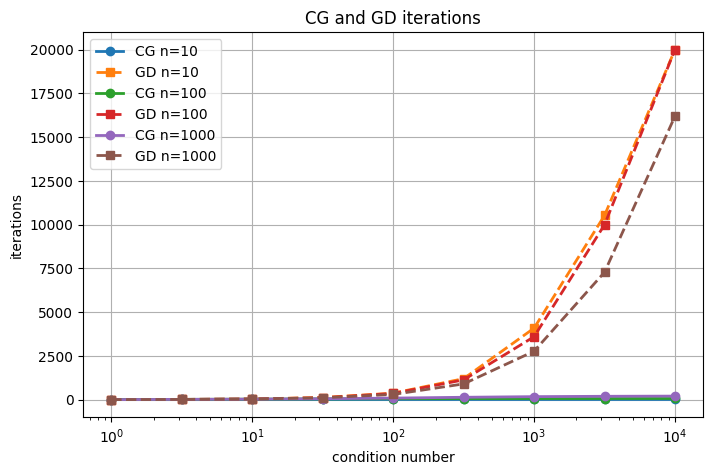

In [3]:
def generate_quadratic(n, kappa, rng):
    diag = np.linspace(1.0, kappa, n)
    diag[0] = 1.0
    diag[-1] = kappa
    A = sp.diags(diag, format='csr')
    b = rng.normal(size=n)
    return A, b


def run_cg_condition_experiment(dimensions=(10, 100, 1000), kappas=None,
                                repeats=5, tolerance=1e-8, seed=67):
    if kappas is None:
        kappas = np.logspace(0, 4, 9)
    rng = np.random.default_rng(seed)
    records = []

    for n in dimensions:
        for kappa in kappas:
            cg_iters = []
            gd_iters = []
            for _ in range(repeats):
                A, b = generate_quadratic(n, kappa, rng)
                x0 = np.zeros(n)
                oracle = QuadraticOracle(A, b)

                _, _, cg_hist = linear_conjugate_gradients(
                    lambda x: A @ x,
                    b,
                    x0,
                    tolerance=tolerance,
                    trace=True,
                )
                _, _, gd_hist = gradient_descent(
                    oracle,
                    x0,
                    tolerance=tolerance,
                    max_iter=20000,
                    line_search_options={'method': 'Best'},
                    trace=True,
                )
                cg_iters.append(max(0, len(cg_hist['residual_norm']) - 1))
                gd_iters.append(len(gd_hist['grad_norm']))

            records.append({
                'n': n,
                'kappa': kappa,
                'cg_iters': float(np.mean(cg_iters)),
                'gd_iters': float(np.mean(gd_iters)),
            })
    return records


def plot_cg_condition_experiment(records):
    dims = sorted(set(r['n'] for r in records))
    plt.figure(figsize=(8, 5))
    for n in dims:
        part = [r for r in records if r['n'] == n]
        plt.plot([r['kappa'] for r in part], [r['cg_iters'] for r in part], 'o-', linewidth=2, label=f'CG n={n}')
        plt.plot([r['kappa'] for r in part], [r['gd_iters'] for r in part], 's--', linewidth=2, label=f'GD n={n}')
    plt.xscale('log')
    plt.xlabel('condition number')
    plt.ylabel('iterations')
    plt.title('CG and GD iterations')
    plt.grid(True)
    plt.legend()

records_22 = run_cg_condition_experiment()
plot_cg_condition_experiment(records_22)


## ???????? hess_vec ????????? ??????????

In [4]:
def check_hess_vec(task='classification', m=30, n=8, points=5, seed=0):
    rng = np.random.default_rng(seed)
    A = rng.normal(size=(m, n))
    y = rng.normal(size=m) if task == 'regression' else rng.choice([-1.0, 1.0], size=m)
    oracle = make_oracle(A, y, task)
    rows = []

    for _ in range(points):
        x = rng.normal(size=n)
        v = rng.normal(size=n)
        hv = oracle.hess_vec(x, v)
        hv_fd = hess_vec_finite_diff(oracle.func, x, v)
        rows.append({
            'abs_error': np.linalg.norm(hv - hv_fd),
            'rel_error': np.linalg.norm(hv - hv_fd) / (np.linalg.norm(hv_fd) + 1e-16),
        })
    return rows

check_hess_vec('regression')
check_hess_vec('classification')


[{'abs_error': np.float64(2.2346439726167627e-05),
  'rel_error': np.float64(1.05343700388638e-05)},
 {'abs_error': np.float64(2.73799835846394e-05),
  'rel_error': np.float64(1.20525600467412e-05)},
 {'abs_error': np.float64(2.8419678584063944e-05),
  'rel_error': np.float64(1.1709246630823903e-05)},
 {'abs_error': np.float64(5.3085516070794515e-05),
  'rel_error': np.float64(1.833569141674277e-05)},
 {'abs_error': np.float64(1.351285668208197e-05),
  'rel_error': np.float64(9.855039784983897e-06)}]

## 2.3. ????? ??????? ??????? L-BFGS

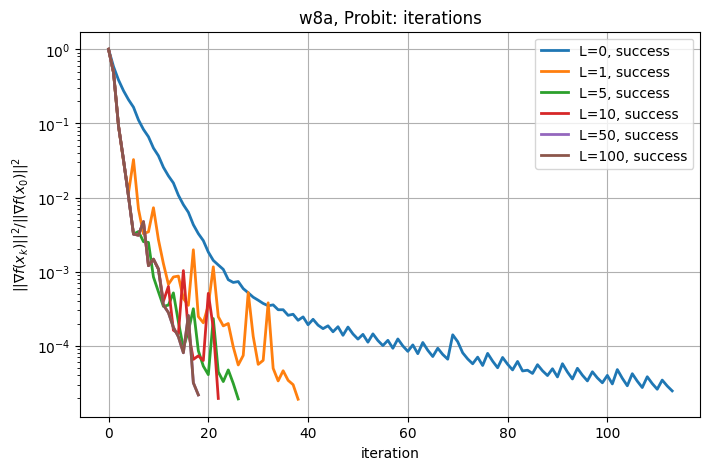

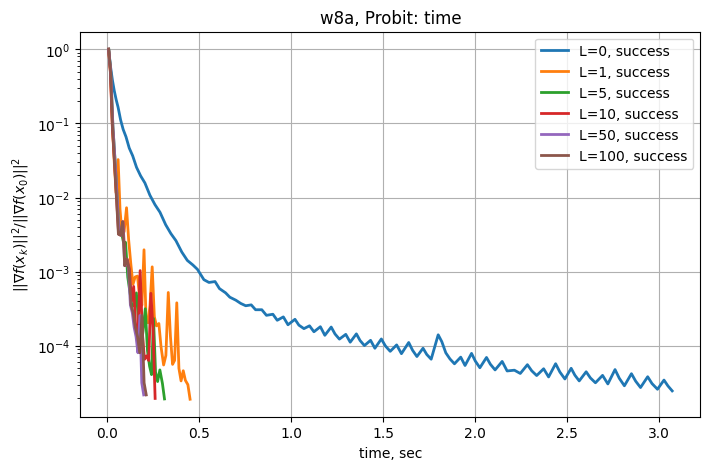

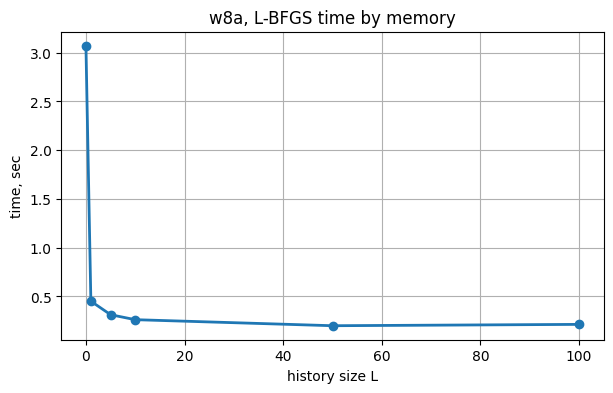

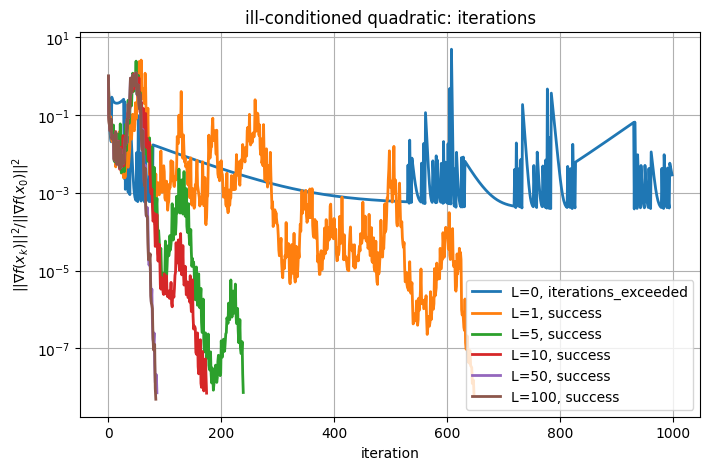

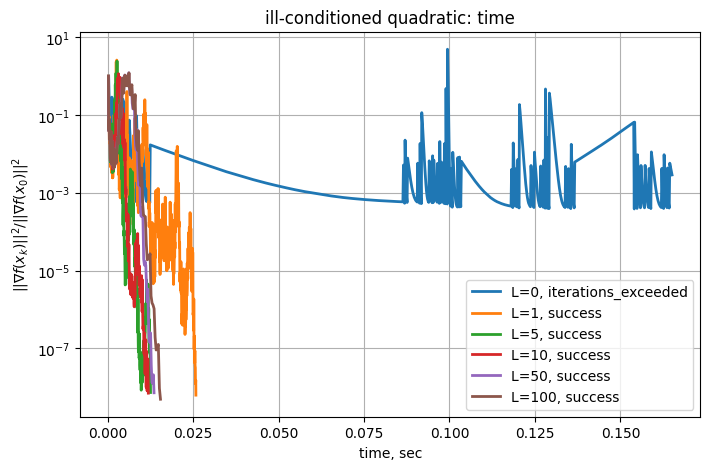

In [5]:
def run_lbfgs_memory_experiment(file_name, task, memories=(0, 1, 5, 10, 50, 100),
                                tolerance=1e-6, max_iter=500):
    A, y = load_data(file_name)
    oracle = make_oracle(A, y, task)
    x0 = np.zeros(A.shape[1])
    results = {}

    for memory in memories:
        _, msg, hist = lbfgs(
            oracle,
            x0,
            tolerance=tolerance,
            max_iter=max_iter,
            memory_size=memory,
            line_search_options={'method': 'Wolfe'},
            trace=True,
        )
        results[f'L={memory}, {msg}'] = hist
    return results


def plot_lbfgs_memory_experiment(results, title):
    plot_rel_grad_by_iter(results, title + ': iterations')
    plot_rel_grad_by_time(results, title + ': time')


def plot_lbfgs_time_by_memory(results, title):
    memories = []
    times = []
    for name, hist in results.items():
        memory = int(name.split(',')[0].split('=')[1])
        memories.append(memory)
        times.append(hist['time'][-1] if hist['time'] else 0.0)
    order = np.argsort(memories)
    plt.figure(figsize=(7, 4))
    plt.plot(np.asarray(memories)[order], np.asarray(times)[order], 'o-', linewidth=2)
    plt.xlabel('history size L')
    plt.ylabel('time, sec')
    plt.title(title)
    plt.grid(True)


def run_lbfgs_bad_quadratic(memories=(0, 1, 5, 10, 50, 100), n=200, kappa=1e5,
                            tolerance=1e-8, max_iter=1000, seed=1):
    rng = np.random.default_rng(seed)
    A, b = generate_quadratic(n, kappa, rng)
    oracle = QuadraticOracle(A, b)
    x0 = np.zeros(n)
    results = {}
    for memory in memories:
        _, msg, hist = lbfgs(oracle, x0, tolerance=tolerance, max_iter=max_iter,
                             memory_size=memory, trace=True)
        results[f'L={memory}, {msg}'] = hist
    return results

res_23 = run_lbfgs_memory_experiment('w8a', 'classification')
plot_lbfgs_memory_experiment(res_23, 'w8a, Probit')
plot_lbfgs_time_by_memory(res_23, 'w8a, L-BFGS time by memory')
bad_quad_23 = run_lbfgs_bad_quadratic()
plot_lbfgs_memory_experiment(bad_quad_23, 'ill-conditioned quadratic')


## 2.4. ????????? ??????? ?? ML-???????

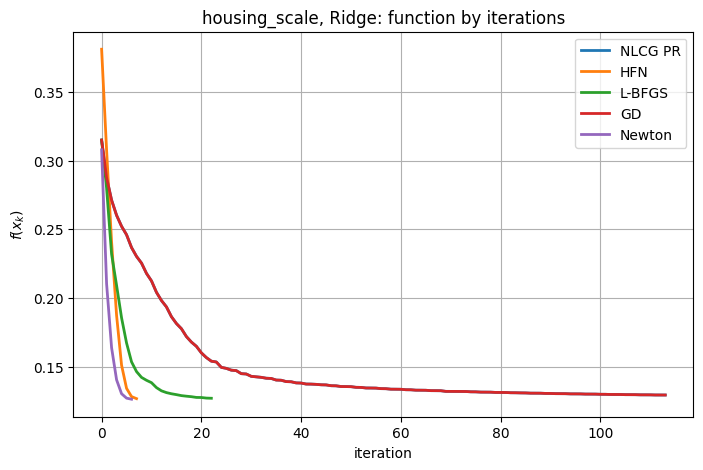

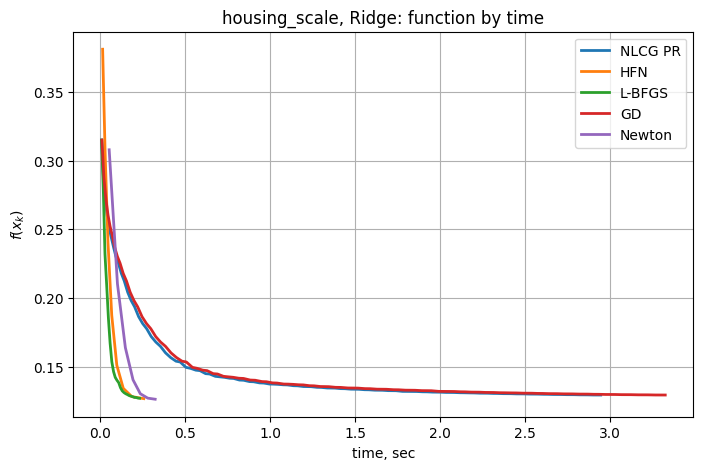

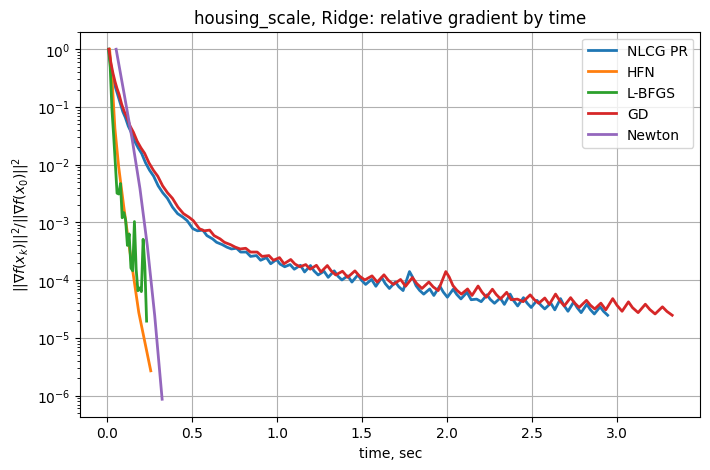

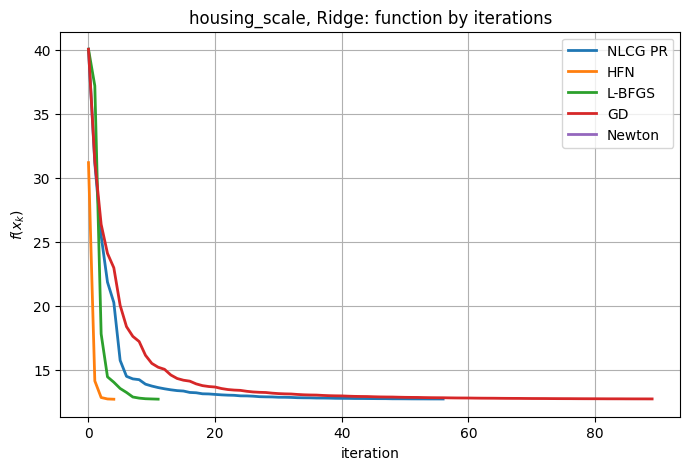

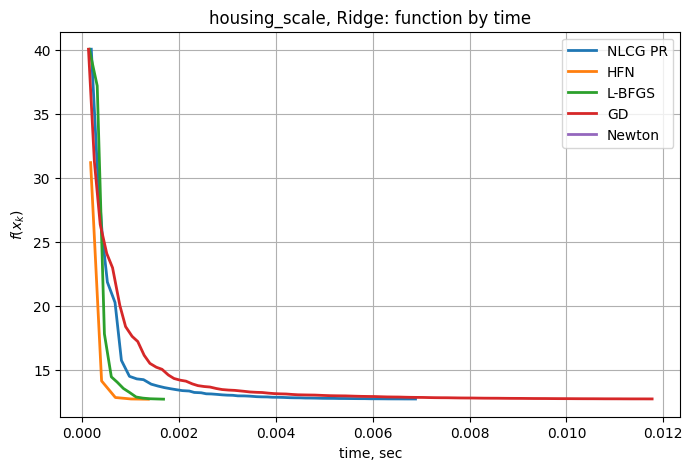

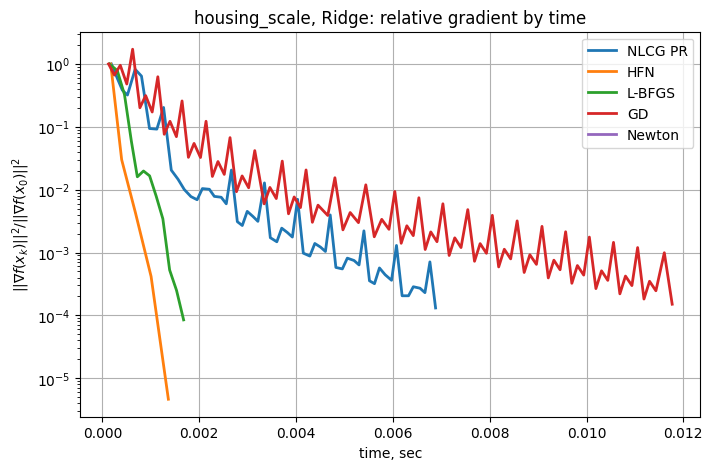

In [6]:
def run_methods_comparison(file_name, task, tolerance=1e-6, max_iter=500,
                           include_newton=True):
    A, y = load_data(file_name)
    oracle = make_oracle(A, y, task)
    x0 = np.zeros(A.shape[1])
    results = {}

    methods = [
        ('NLCG PR', lambda: nonlinear_conjugate_gradients(
            oracle, x0, tolerance=tolerance, max_iter=max_iter, beta_formula='PR',
            powell_restart=True, trace=True)),
        ('HFN', lambda: hessian_free_newton(
            oracle, x0, tolerance=tolerance, max_iter=max_iter, trace=True)),
        ('L-BFGS', lambda: lbfgs(
            oracle, x0, tolerance=tolerance, max_iter=max_iter, memory_size=10, trace=True)),
        ('GD', lambda: gradient_descent(
            oracle, x0, tolerance=tolerance, max_iter=max_iter, trace=True)),
    ]
    if include_newton and A.shape[1] <= 2500:
        dense_oracle = DenseHessianOracle(oracle)
        methods.append(('Newton', lambda: newton(
            dense_oracle, x0, tolerance=tolerance, max_iter=min(max_iter, 100), trace=True)))

    messages = {}
    for name, runner in methods:
        _, msg, hist = runner()
        results[name] = hist
        messages[name] = msg
    return results, messages


def plot_methods_comparison(results, title):
    plot_func_by_iter(results, title + ': function by iterations')
    plot_func_by_time(results, title + ': function by time')
    plot_rel_grad_by_time(results, title + ': relative gradient by time')

res_24, msg_24 = run_methods_comparison('w8a', 'classification')
plot_methods_comparison(res_24, 'housing_scale, Ridge')
#msg_24
res_24, msg_24 = run_methods_comparison('housing_scale', 'regression')
plot_methods_comparison(res_24, 'housing_scale, Ridge')


## 2.5. ??????????????????? ????? ????????

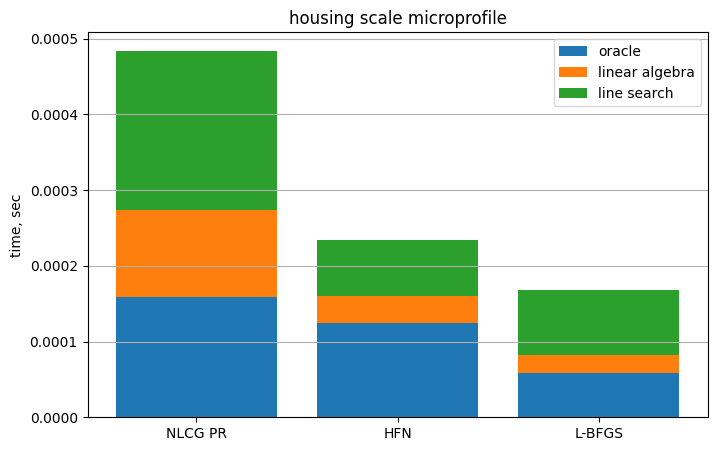

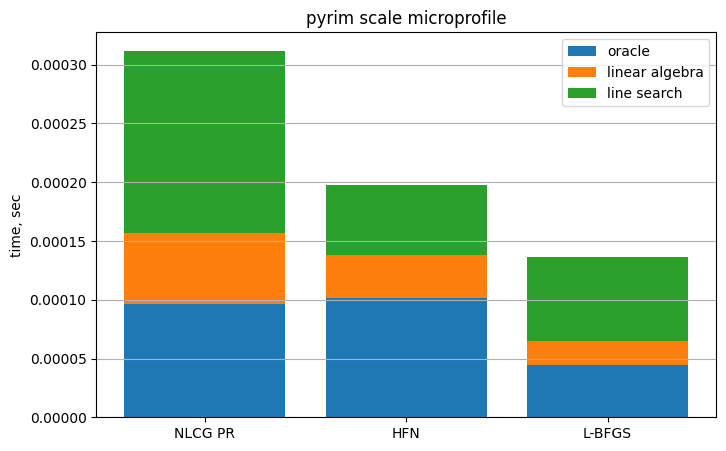

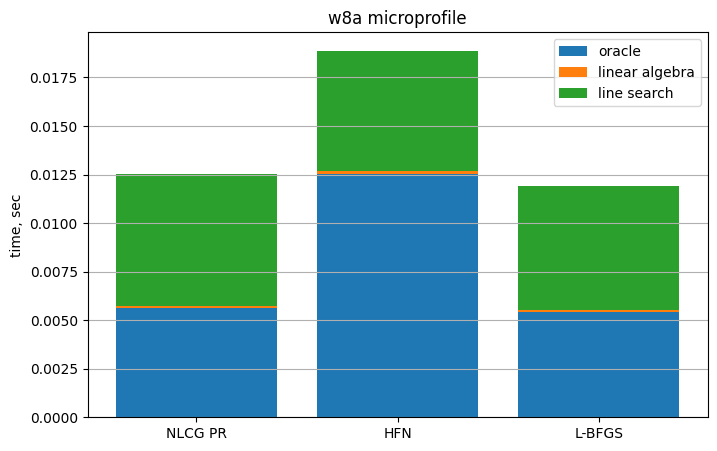

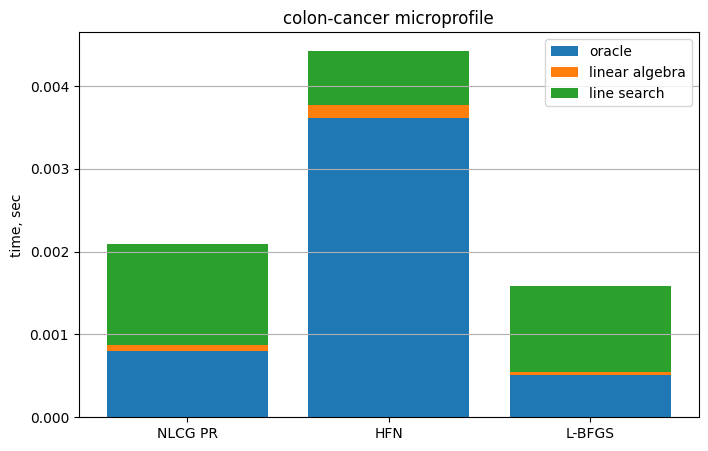

In [7]:
class TimedOracle:
    def __init__(self, oracle):
        self.oracle = oracle
        self.elapsed = defaultdict_float()

    def _time(self, key, func, *args):
        start = time.perf_counter()
        value = func(*args)
        self.elapsed[key] += time.perf_counter() - start
        return value

    def func(self, x):
        return self._time('func', self.oracle.func, x)

    def grad(self, x):
        return self._time('grad', self.oracle.grad, x)

    def hess(self, x):
        return self._time('hess', self.oracle.hess, x)

    def hess_vec(self, x, v):
        return self._time('hess_vec', self.oracle.hess_vec, x, v)

    def func_directional(self, x, d, alpha):
        return self.func(x + alpha * d)

    def grad_directional(self, x, d, alpha):
        return self.grad(x + alpha * d).dot(d)

    @property
    def oracle_time(self):
        return sum(self.elapsed.values())


class defaultdict_float(dict):
    def __missing__(self, key):
        self[key] = 0.0
        return self[key]


class TimedLineSearchTool(LineSearchTool):
    def __init__(self, method='Wolfe', **kwargs):
        super().__init__(method, **kwargs)
        self.elapsed = 0.0
        self.oracle_elapsed = 0.0

    def line_search(self, oracle, x_k, d_k, previous_alpha=None):
        oracle_before = getattr(oracle, 'oracle_time', 0.0)
        start = time.perf_counter()
        alpha = super().line_search(oracle, x_k, d_k, previous_alpha)
        self.elapsed += time.perf_counter() - start
        self.oracle_elapsed += getattr(oracle, 'oracle_time', 0.0) - oracle_before
        return alpha


def profile_method_once(method_name, oracle, x0):
    timed_oracle = TimedOracle(oracle)
    timed_ls = TimedLineSearchTool('Wolfe')
    start = time.perf_counter()

    if method_name == 'NLCG PR':
        nonlinear_conjugate_gradients(timed_oracle, x0, max_iter=1, trace=True,
                                      beta_formula='PR', powell_restart=True,
                                      line_search_options=timed_ls)
    elif method_name == 'HFN':
        hessian_free_newton(timed_oracle, x0, max_iter=1, trace=True,
                            line_search_options=timed_ls)
    elif method_name == 'L-BFGS':
        lbfgs(timed_oracle, x0, max_iter=1, memory_size=10, trace=True,
              line_search_options=timed_ls)
    else:
        raise ValueError(method_name)

    total = time.perf_counter() - start
    oracle_outside_ls = timed_oracle.oracle_time - timed_ls.oracle_elapsed
    linear_algebra = max(0.0, total - timed_ls.elapsed - oracle_outside_ls)
    return {
        'method': method_name,
        'oracle': oracle_outside_ls,
        'linear_algebra': linear_algebra,
        'line_search': timed_ls.elapsed,
        'total': total,
    }


def run_microprofile(file_name, task):
    A, y = load_data(file_name)
    oracle = make_oracle(A, y, task)
    x0 = np.zeros(A.shape[1])
    return [profile_method_once(name, oracle, x0) for name in ['NLCG PR', 'HFN', 'L-BFGS']]


def plot_microprofile(rows, title):
    labels = [r['method'] for r in rows]
    oracle = np.array([r['oracle'] for r in rows])
    algebra = np.array([r['linear_algebra'] for r in rows])
    search = np.array([r['line_search'] for r in rows])
    x = np.arange(len(labels))
    plt.figure(figsize=(8, 5))
    plt.bar(x, oracle, label='oracle')
    plt.bar(x, algebra, bottom=oracle, label='linear algebra')
    plt.bar(x, search, bottom=oracle + algebra, label='line search')
    plt.xticks(x, labels)
    plt.ylabel('time, sec')
    plt.title(title)
    plt.grid(True, axis='y')
    plt.legend()

rows_25 = run_microprofile('housing_scale', 'regression')
plot_microprofile(rows_25, 'housing scale microprofile')

rows_25 = run_microprofile('pyrim', 'regression')
plot_microprofile(rows_25, 'pyrim scale microprofile')

rows_25 = run_microprofile('w8a', 'classification')
plot_microprofile(rows_25, 'w8a microprofile')

rows_25 = run_microprofile('colon-cancer', 'classification')
plot_microprofile(rows_25, 'colon-cancer microprofile')

## 2.6. ??????????????? ???????? ?????? ???????? ????????????

In [ ]:
def split_dataset(file_name, task, test_size=0.2, seed=67):
    A, y = load_data(file_name)
    y = prepare_labels(y, task)
    stratify = y if task == 'classification' else None
    return train_test_split(A, y, test_size=test_size, random_state=seed, stratify=stratify)


def test_metric(A_test, y_test, x, task):
    pred = A_test @ x
    if task == 'classification':
        labels = np.where(pred >= 0, 1.0, -1.0)
        return accuracy_score(y_test, labels)
    return {
        'mse': mean_squared_error(y_test, pred),
        'mae': mean_absolute_error(y_test, pred),
    }


def run_quality_experiment(file_name, task, regcoef=None, c=None, tolerance=1e-8,
                           max_iter=1000, seed=67):
    A_train, A_test, y_train, y_test = split_dataset(file_name, task, seed=seed)
    if c is not None:
        regcoef = c / A_train.shape[0]
    oracle = make_oracle(A_train, y_train, task, regcoef=regcoef)
    x0 = np.zeros(A_train.shape[1])
    rows = []

    def callback(x, grad, k, elapsed):
        metric = test_metric(A_test, y_test, x, task)
        row = {
            'iteration': k,
            'time': elapsed,
            'f_train': oracle.func(x),
            'grad_norm': np.linalg.norm(grad),
        }
        if task == 'classification':
            row['accuracy'] = metric
        else:
            row.update(metric)
        rows.append(row)

    _, msg, hist = lbfgs(
        oracle,
        x0,
        tolerance=tolerance,
        max_iter=max_iter,
        memory_size=10,
        trace=True,
        callback=callback,
    )
    return rows, hist, msg


def run_lambda_cm_experiment(file_name, task, c_values, tolerance=1e-8,
                             max_iter=1000, seed=67):
    A, _ = load_data(file_name)
    m = A.shape[0]
    results = []
    for c in c_values:
        rows, hist, msg = run_quality_experiment(
            file_name,
            task,
            c=c,
            tolerance=tolerance,
            max_iter=max_iter,
            seed=seed,
        )
        last = rows[-1]
        result = {
            'c': c,
            'lambda': c / m,
            'msg': msg,
            'iterations': len(rows) - 1,
            'rows': rows,
            'hist': hist,
            'f_train': last['f_train'],
            'grad_norm': last['grad_norm'],
        }
        if task == 'classification':
            result['accuracy'] = last['accuracy']
        else:
            result['mse'] = last['mse']
            result['mae'] = last['mae']
        results.append(result)
    return results


def plot_lambda_cm_experiment(results, task, dataset_name):
    for result in results:
        c = result['c']
        lambd = result['lambda']
        title = f"{dataset_name}: optimization vs test quality (c={c:g}, lambda={lambd:.3e})"
        plot_quality_experiment(result['rows'], task, title)


def plot_quality_experiment(rows, task, title):
    xs = [r['iteration'] for r in rows]
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.semilogy(xs, [r['f_train'] for r in rows], linewidth=2, label='f_train')
    ax1.semilogy(xs, [r['grad_norm'] for r in rows], linewidth=2, label='grad_norm')
    ax1.set_xlabel('iteration')
    ax1.set_ylabel('train objective / grad norm')
    ax1.grid(True)
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    if task == 'classification':
        ax2.plot(xs, [r['accuracy'] for r in rows], color='tab:red', linewidth=2, label='accuracy')
        ax2.set_ylabel('accuracy')
    else:
        ax2.semilogy(xs, [r['mse'] for r in rows], color='tab:red', linewidth=2, label='mse')
        ax2.semilogy(xs, [r['mae'] for r in rows], color='tab:green', linewidth=2, label='mae')
        ax2.set_ylabel('mse / mae')

    ax2.legend(loc='upper right')
    plt.title(title)

# rows_26, hist_26, msg_26 = run_quality_experiment('housing_scale', 'regression')
# plot_quality_experiment(rows_26, 'regression', 'housing scale: optimization vs test quality')

# rows_26, hist_26, msg_26 = run_quality_experiment('pyrim', 'regression')
# plot_quality_experiment(rows_26, 'regression', 'pyrim: optimization vs test quality')
# #
# rows_26, hist_26, msg_26 = run_quality_experiment('w8a', 'classification')
# plot_quality_experiment(rows_26, 'classification', 'w8a: optimization vs test quality')
#
# rows_26, hist_26, msg_26 = run_quality_experiment('colon-cancer', 'classification')
# plot_quality_experiment(rows_26, 'classification', 'colon-cancer: optimization vs test quality')

lambda_results = run_lambda_cm_experiment('pyrim', 'regression', c_values=[1e-3, 1e-2, 1e-1, 1, 10])
plot_lambda_cm_experiment(lambda_results, 'regression', 'pyrim')


## 2.7. ?????????????? ???? 3: PR ?????? Hager-Zhang ? ??????? ???????

In [ ]:
TRACK3_CONFIGS = {
    'PR no Powell': {
        'beta_formula': 'PR',
        'powell_restart': False,
        'reset_negative_beta': False,
        'descent_restart': False,
    },
    'PR Powell': {
        'beta_formula': 'PR',
        'powell_restart': True,
        'reset_negative_beta': False,
        'descent_restart': True,
    },
    'HZ no Powell': {
        'beta_formula': 'HZ',
        'powell_restart': False,
        'reset_negative_beta': False,
        'descent_restart': False,
    },
    'HZ Powell': {
        'beta_formula': 'HZ',
        'powell_restart': True,
        'reset_negative_beta': False,
        'descent_restart': True,
    },
}


def run_track3_experiment(file_name, task, tolerance=1e-6, max_iter=500):
    A, y = load_data(file_name)
    oracle = make_oracle(A, y, task)
    x0 = np.zeros(A.shape[1])
    results = {}
    messages = {}

    for name, options in TRACK3_CONFIGS.items():
        _, msg, hist = nonlinear_conjugate_gradients(
            oracle,
            x0,
            tolerance=tolerance,
            max_iter=max_iter,
            line_search_options={'method': 'Wolfe'},
            trace=True,
            **options,
        )
        results[name] = hist
        messages[name] = msg
    return results, messages


def track3_summary(results, messages):
    rows = []
    for name, hist in results.items():
        restarts = int(np.sum(hist.get('restart', [])))
        iters = len(hist.get('grad_norm', []))
        rows.append({
            'method': name,
            'message': messages[name],
            'iterations': iters,
            'time': hist['time'][-1] if hist.get('time') else 0.0,
            'restarts': restarts,
            'restart_rate': restarts / max(1, iters),
            'final_rel_grad_sq': rel_grad_sq(hist)[-1] if iters else np.nan,
        })
    return rows


def plot_track3_cos(results, title):
    plt.figure(figsize=(8, 5))
    for name in ['PR no Powell', 'HZ no Powell']:
        hist = results[name]
        plt.plot(hist['cos'], linewidth=2, label=name)
    plt.axhline(0.2, color='black', linestyle='--', linewidth=1, label='Powell threshold')
    plt.xlabel('iteration')
    plt.ylabel(r'$cos(\theta_k)$')
    plt.title(title)
    plt.grid(True)
    plt.legend()


def plot_track3_convergence(results, title):
    plot_rel_grad_by_iter(results, title + ': relative gradient by iterations')
    plot_rel_grad_by_time(results, title + ': relative gradient by time')

res_27, msg_27 = run_track3_experiment('w8a', 'classification')
plot_track3_cos(res_27, 'w8a: loss of orthogonality')
plot_track3_convergence(res_27, 'w8a: PR vs HZ')
track3_summary(res_27, msg_27)
